In [37]:

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
TRAIN_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
TEST_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test"

In [38]:

print(f"Training folder exists: {os.path.exists(TRAIN_DIR)}")
print(f"Test folder exists: {os.path.exists(TEST_DIR)}")


Training folder exists: True
Test folder exists: True


In [39]:

classes = sorted(os.listdir(TRAIN_DIR))
print(f"\n CLASS INFORMATION:")
print(f"Number of classes: {len(classes)}")
print("All classes:", classes)



 CLASS INFORMATION:
Number of classes: 29
All classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [40]:
class_counts = {}
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        num_images = len(image_files)
        class_counts[cls] = num_images
        print(f"  {cls}: {num_images} images")

  A: 3000 images
  B: 3000 images
  C: 3000 images
  D: 3000 images
  E: 3000 images
  F: 3000 images
  G: 3000 images
  H: 3000 images
  I: 3000 images
  J: 3000 images
  K: 3000 images
  L: 3000 images
  M: 3000 images
  N: 3000 images
  O: 3000 images
  P: 3000 images
  Q: 3000 images
  R: 3000 images
  S: 3000 images
  T: 3000 images
  U: 3000 images
  V: 3000 images
  W: 3000 images
  X: 3000 images
  Y: 3000 images
  Z: 3000 images
  del: 3000 images
  nothing: 3000 images
  space: 3000 images


In [41]:
total_images = sum(class_counts.values())
print(f"Total training images: {total_images:,}")
print(f"Average per class: {total_images/len(classes):.0f} images")


Total training images: 87,000
Average per class: 3000 images


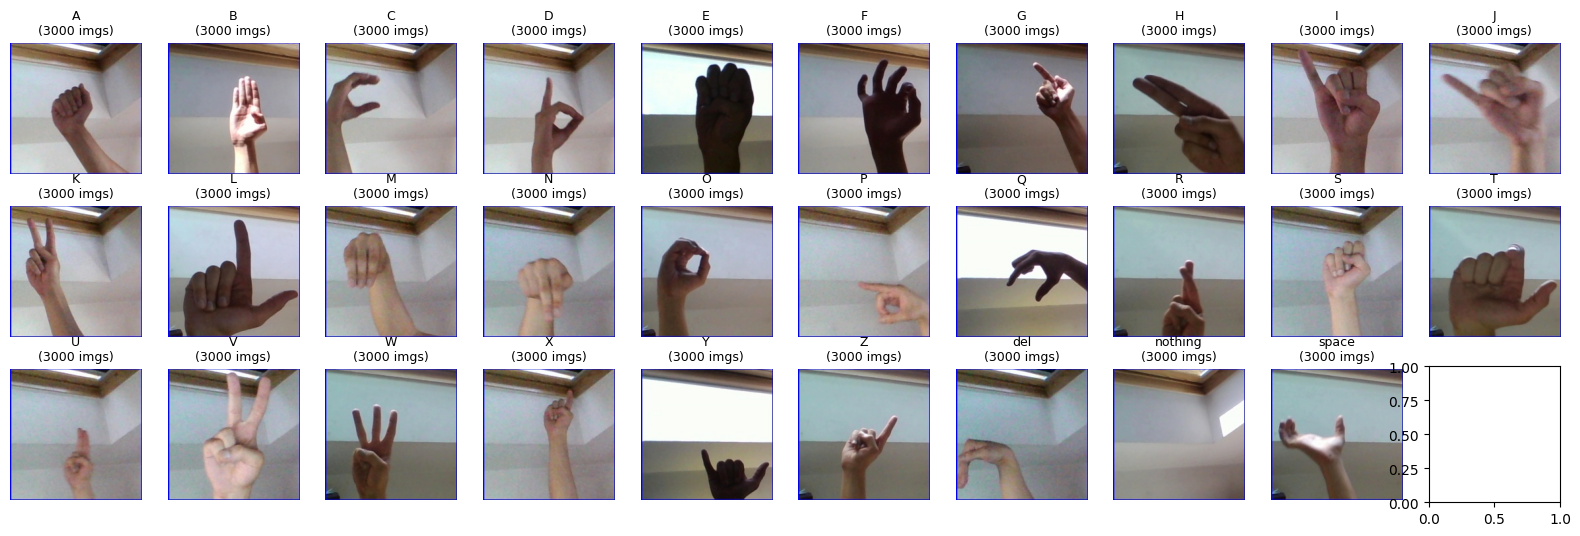

In [42]:
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i, cls in enumerate(classes[:30]):  
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if image_files:
            img_path = os.path.join(cls_path, image_files[0])
            img = mpimg.imread(img_path)
            
            row = i // 10
            col = i % 10
            axes[row, col].imshow(img)
            axes[row, col].set_title(f"{cls}\n({class_counts[cls]} imgs)", fontsize=9)
            axes[row, col].axis('off')

In [43]:

sample_class = classes[0]
sample_path = os.path.join(TRAIN_DIR, sample_class)
sample_image = [f for f in os.listdir(sample_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))][0]
img = mpimg.imread(os.path.join(sample_path, sample_image))

print(f"Image shape: {img.shape} (Height, Width, Channels)")
print(f"Image dtype: {img.dtype}")
print(f"Pixel value range: {img.min()} to {img.max()}")


Image shape: (200, 200, 3) (Height, Width, Channels)
Image dtype: uint8
Pixel value range: 0 to 255


In [44]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
TRAIN_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train"
TEST_DIR = "/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test"

IMG_SIZE = (224, 224)  
BATCH_SIZE = 32
SEED = 42
VALIDATION_SPLIT = 0.2  # 20% for validation


In [45]:
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0, 1]
    validation_split=VALIDATION_SPLIT, 
    
    rotation_range=15,        
    width_shift_range=0.1,    
    height_shift_range=0.1,   
    zoom_range=0.1,          
    shear_range=0.1,         
    fill_mode='nearest',    
    
    horizontal_flip=False,    
    
)


In [46]:

train_generator = train_datagen.flow_from_directory(
TRAIN_DIR,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='training',      
seed=SEED,
shuffle=True
)


Found 69600 images belonging to 29 classes.


In [47]:

validation_generator = train_datagen.flow_from_directory(
TRAIN_DIR,
target_size=IMG_SIZE,
batch_size=BATCH_SIZE,
class_mode='categorical',
subset='validation',      
seed=SEED,
shuffle=False           
)


Found 17400 images belonging to 29 classes.


In [48]:

print(f"Training samples: {train_generator.samples:,}")
print(f"Validation samples: {validation_generator.samples:,}")
print(f"Total samples: {train_generator.samples + validation_generator.samples:,}")
print(f"Number of classes: {len(train_generator.class_indices)}")
print(f"Classes: {list(train_generator.class_indices.keys())}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}")
print(f"Training batches: {len(train_generator)}")
print(f"Validation batches: {len(validation_generator)}")


Training samples: 69,600
Validation samples: 17,400
Total samples: 87,000
Number of classes: 29
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Batch size: 32
Image size: (224, 224)
Training batches: 2175
Validation batches: 544


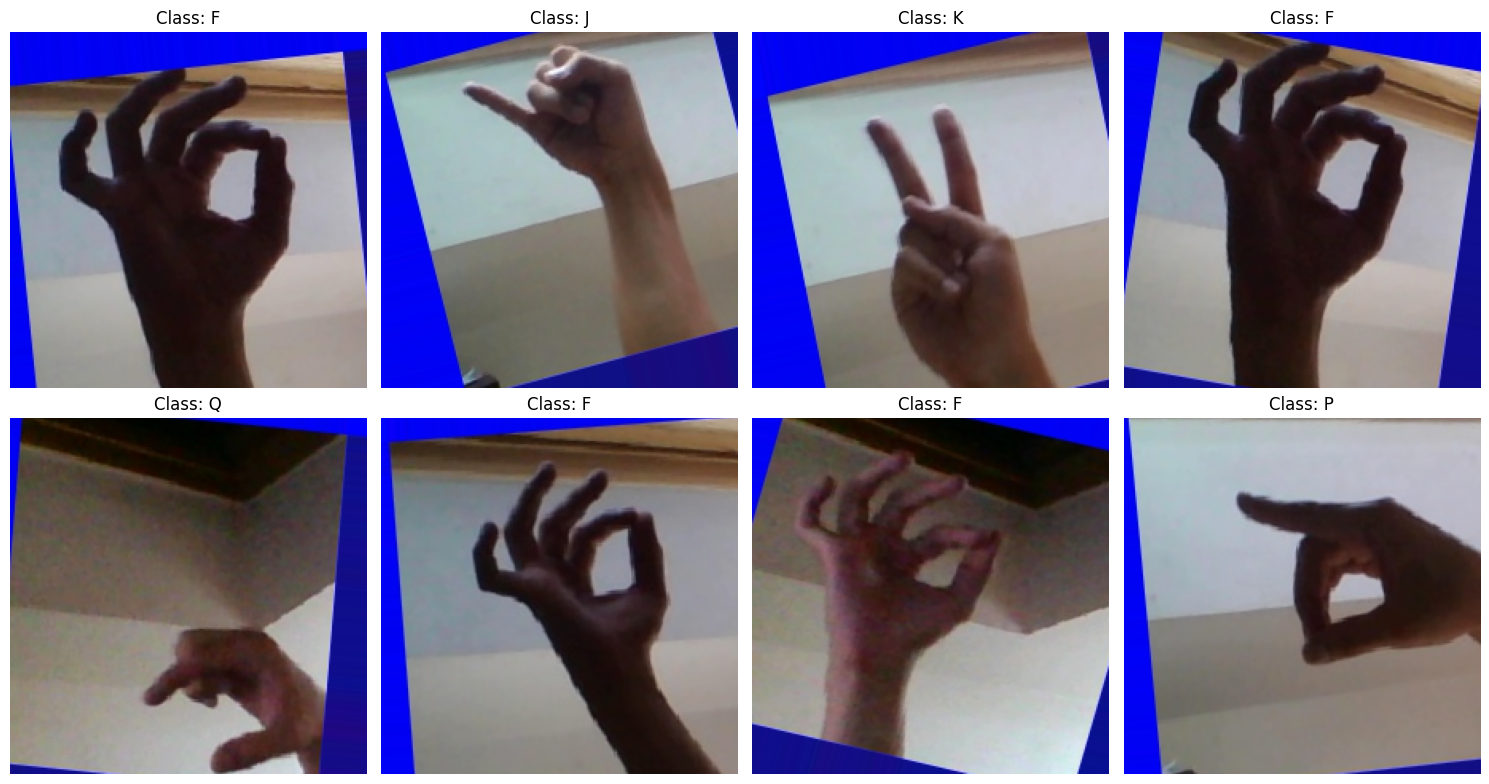

In [49]:
images, labels = next(train_generator)

plt.figure(figsize=(15, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    
    class_idx = labels[i].argmax()
    class_name = list(train_generator.class_indices.keys())[class_idx]
    
    plt.title(f"Class: {class_name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:

print(f"Pixel range before: 0-255")
print(f"Pixel range after: {images.min():.3f} to {images.max():.3f}")
print(f"Image shape in batch: {images[0].shape}")


Pixel range before: 0-255
Pixel range after: 0.000 to 1.000
Image shape in batch: (224, 224, 3)


In [51]:
test_base = "/kaggle/input/asl-alphabet"

if os.path.exists(TEST_DIR):
    print(f"Test directory exists: {TEST_DIR}")
    
    # List what's inside
    print(f"Contents of test directory:")
    for item in os.listdir(TEST_DIR):
        item_path = os.path.join(TEST_DIR, item)
        if os.path.isdir(item_path):
            print(f"{item}/ (directory)")
        else:
            print(f"{item} (file)")
    

Test directory exists: /kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test
Contents of test directory:
A_test.jpg (file)
E_test.jpg (file)
L_test.jpg (file)
N_test.jpg (file)
S_test.jpg (file)
D_test.jpg (file)
G_test.jpg (file)
I_test.jpg (file)
W_test.jpg (file)
M_test.jpg (file)
nothing_test.jpg (file)
X_test.jpg (file)
H_test.jpg (file)
Q_test.jpg (file)
C_test.jpg (file)
T_test.jpg (file)
P_test.jpg (file)
V_test.jpg (file)
Y_test.jpg (file)
U_test.jpg (file)
space_test.jpg (file)
O_test.jpg (file)
B_test.jpg (file)
R_test.jpg (file)
F_test.jpg (file)
Z_test.jpg (file)
J_test.jpg (file)
K_test.jpg (file)


In [52]:
test_base_path = "/kaggle/input/asl-alphabet/asl_alphabet_test"
if os.path.exists(test_base_path):
    for root, dirs, files in os.walk(test_base_path):
        level = root.replace(test_base_path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)
        
        for file in files[:5]:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")
    
    test_count = 0
    for root, dirs, files in os.walk(test_base_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                test_count += 1
    
    
   

asl_alphabet_test/
  asl_alphabet_test/
    A_test.jpg
    E_test.jpg
    L_test.jpg
    N_test.jpg
    S_test.jpg
    ... and 23 more files



 Loading data...
Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Data loaded!
   Classes: 29
   Training samples: 69600
   Validation samples: 17400
 Model built!
   Total parameters: 3,059,805
Epoch 1/8
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.6534 - loss: 1.1911 - top_3_accuracy: 0.8283
Epoch 1: val_accuracy improved from -inf to 0.80816, saving model to /kaggle/working/best_model_phase1.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1278s 583ms/step - accuracy: 0.6535 - loss: 1.1909 - top_3_accuracy: 0.8283 - val_accuracy: 0.8082 - val_loss: 0.6033 - val_top_3_accuracy: 0.9364 - learning_rate: 0.0010
Epoch 2/8
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.8305 - loss: 0.5298 - top_3_accuracy: 0.9546
Epoch 2: val_accuracy improved from 0.80816 to 0.82264, saving model to /kaggle/working/best_model_phase1.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1123s 516ms/step - accuracy: 0.8305 - loss: 0.5298 - top_3_accuracy: 0.9546 - val_accuracy: 0.8226 - val_loss: 0.5904 - val_top_3_accuracy: 0.9438 - learning_rate: 0.0010
Epoch 3/8
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.8493 - loss: 0.4748 - top_3_accuracy: 0.9584
Epoch 3: val_accuracy improved from 0.82264 to 0.82299, saving model to /kaggle/working/best_model_phase1.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1062s 488ms/step - accuracy: 0.8493 - loss: 0.4748 - top_3_accuracy: 0.9584 - val_accuracy: 0.8230 - val_loss: 0.6275 - val_top_3_accuracy: 0.9345 - learning_rate: 0.0010
Epoch 4/8
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.8692 - loss: 0.4138 - top_3_accuracy: 0.9661
Epoch 4: val_accuracy improved from 0.82299 to 0.82414, saving model to /kaggle/working/best_model_phase1.h5



Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1062s 488ms/step - accuracy: 0.8692 - loss: 0.4138 - top_3_accuracy: 0.9661 - val_accuracy: 0.8241 - val_loss: 0.5999 - val_top_3_accuracy: 0.9416 - learning_rate: 0.0010
Epoch 5/8
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.8842 - loss: 0.3678 - top_3_accuracy: 0.9704
Epoch 5: val_accuracy improved from 0.82414 to 0.83362, saving model to /kaggle/working/best_model_phase1.h5


...

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 940s 432ms/step - accuracy: 0.9982 - loss: 0.6778 - top_3_accuracy: 0.9996 - val_accuracy: 0.9733 - val_loss: 0.7151 - val_top_3_accuracy: 0.9972 - learning_rate: 2.5000e-05
Epoch 14/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9982 - loss: 0.6760 - top_3_accuracy: 0.9997
Epoch 14: val_accuracy did not improve from 0.97983


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 929s 427ms/step - accuracy: 0.9982 - loss: 0.6760 - top_3_accuracy: 0.9997 - val_accuracy: 0.9784 - val_loss: 0.7050 - val_top_3_accuracy: 0.9992 - learning_rate: 2.5000e-05
Epoch 15/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.9986 - loss: 0.6733 - top_3_accuracy: 0.9997
Epoch 15: val_accuracy did not improve from 0.97983



Epoch 15: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 963s 443ms/step - accuracy: 0.9986 - loss: 0.6733 - top_3_accuracy: 0.9997 - val_accuracy: 0.9734 - val_loss: 0.7228 - val_top_3_accuracy: 0.9971 - learning_rate: 2.5000e-05
Restoring model weights from the end of the best epoch: 12.


Saved: /kaggle/working/asl_model_final.h5 (33.76 MB)


Saved: /kaggle/working/asl_model_final.keras (33.96 MB)
Saved: asl_model_final.h5 (33.76 MB)
Saved: asl_model_final.keras (33.96 MB)


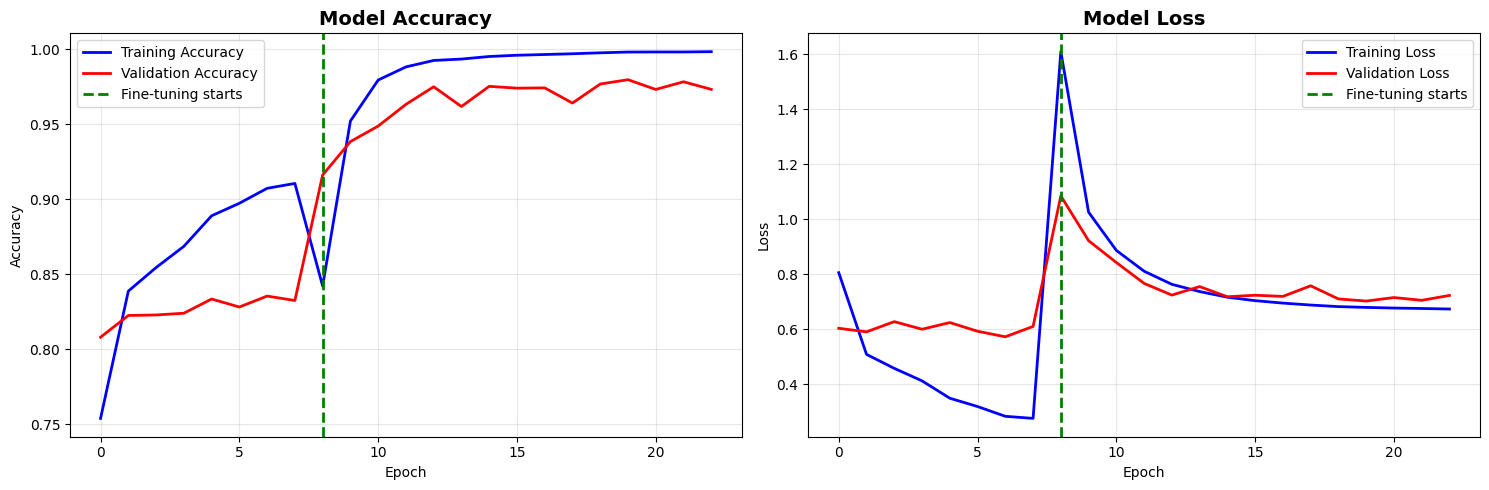

544/544 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.9875 - loss: 0.6808 - top_3_accuracy: 0.9990
   Validation Accuracy:  97.98%
   Top-3 Accuracy:       99.84%
   Validation Loss:      0.7023
   Training Accuracy:    99.85%
   Overfitting Gap:      1.87%
544/544 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step


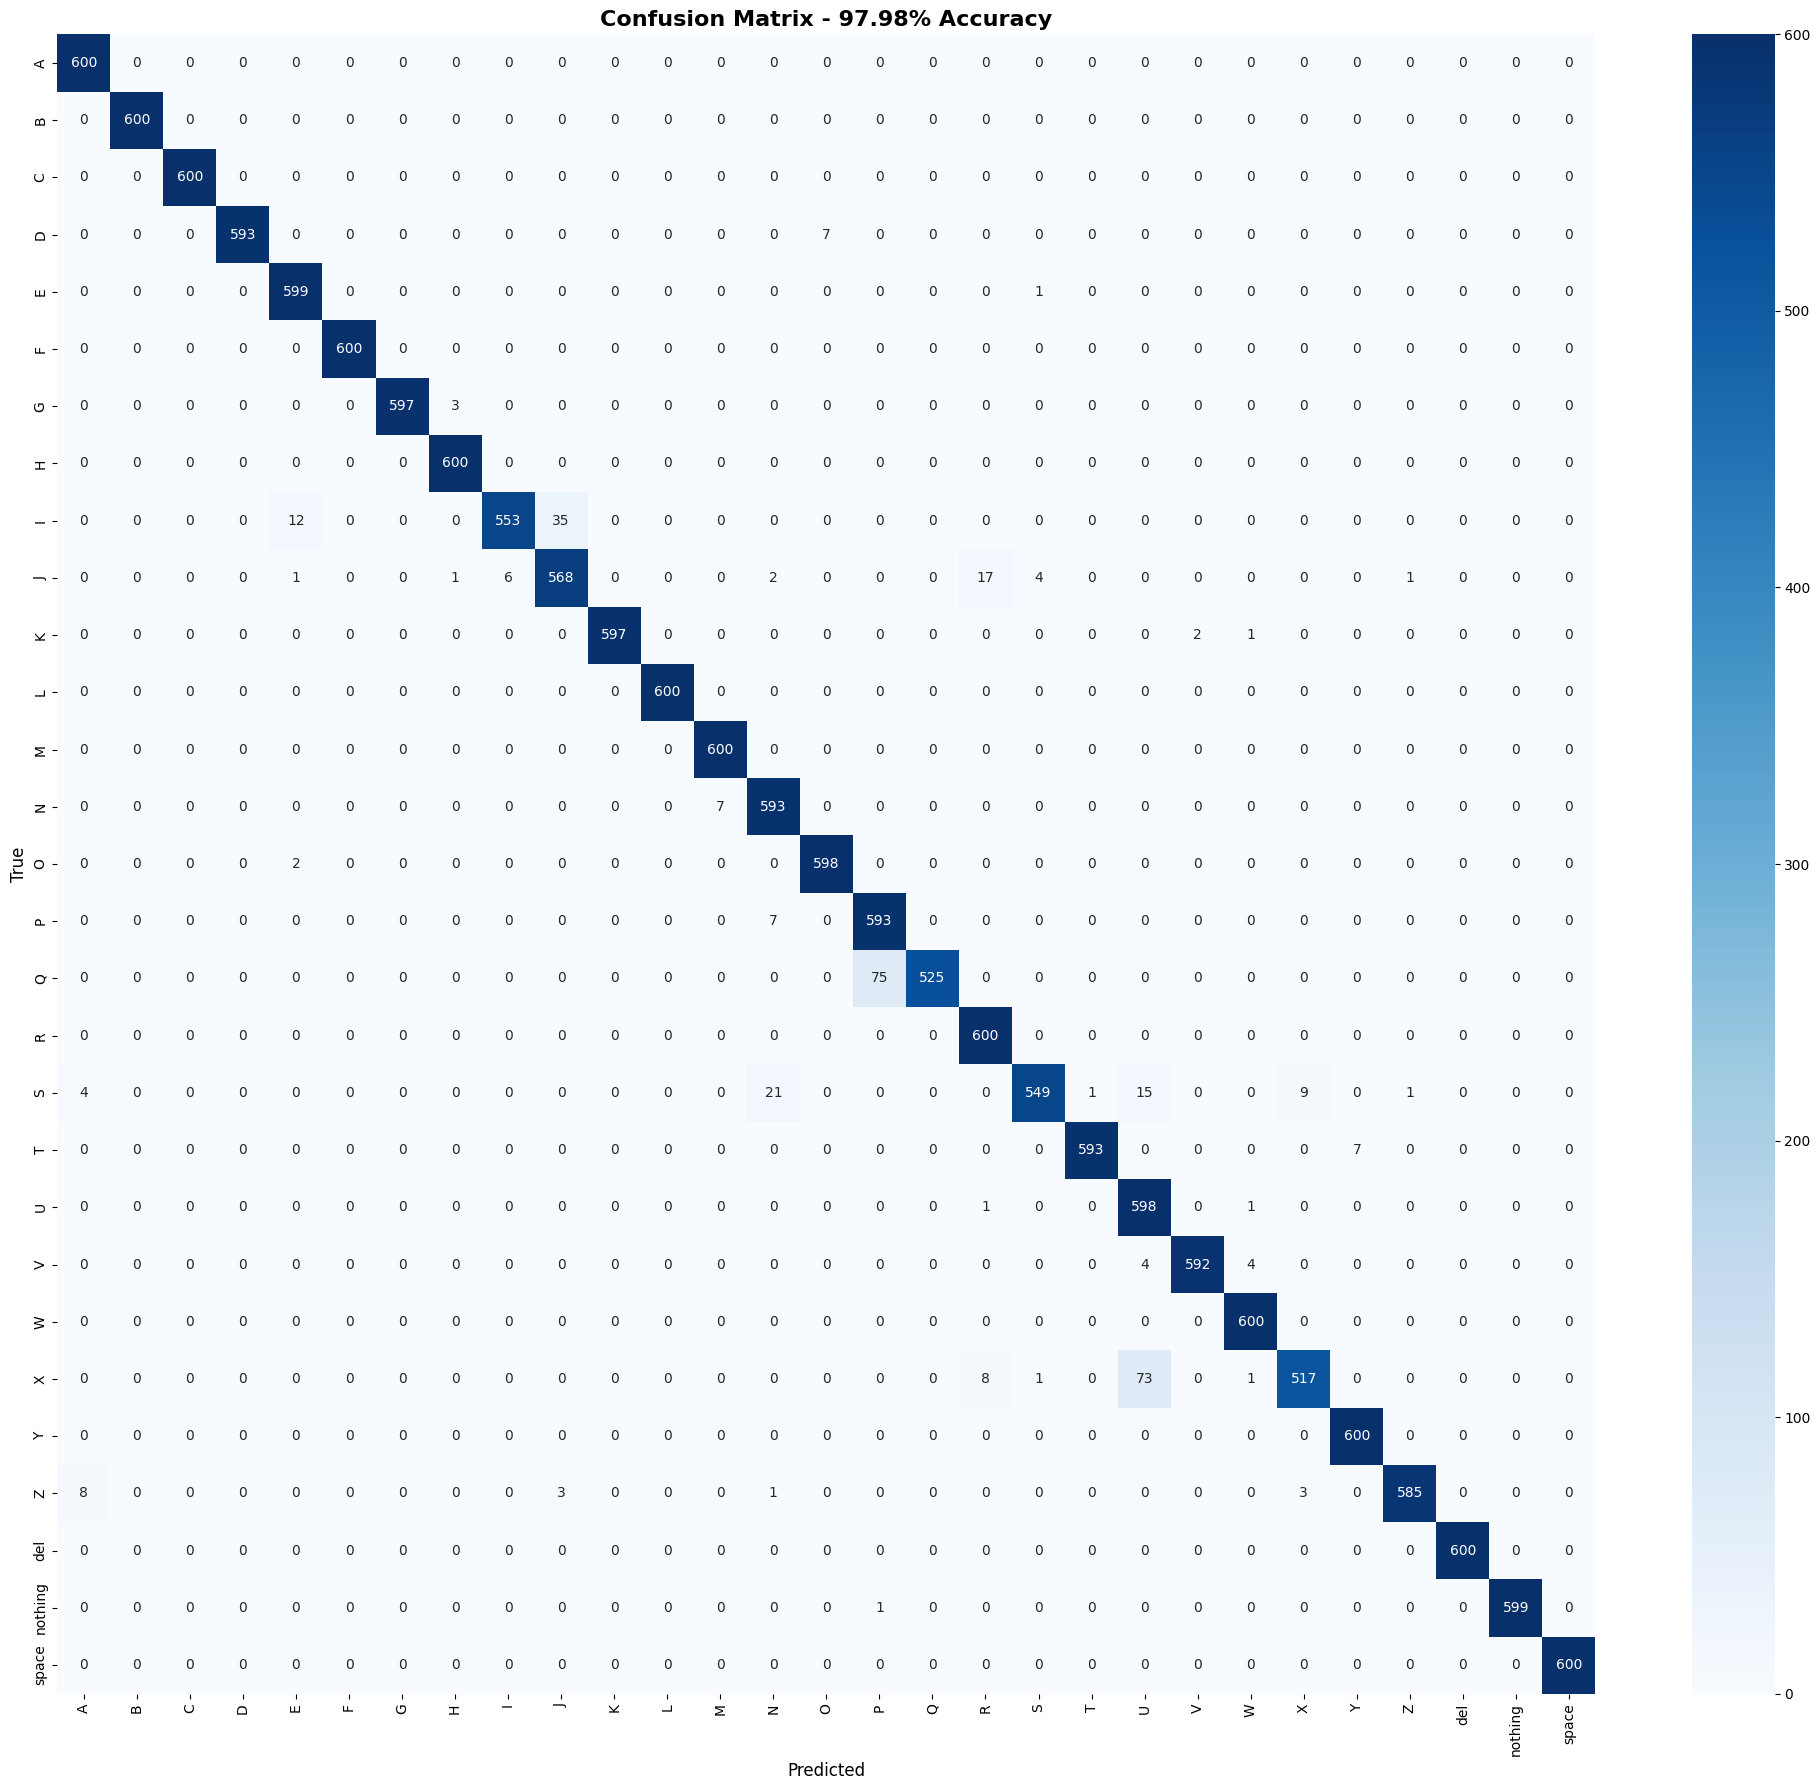


 Classification Report:
              precision    recall  f1-score   support

           A       0.98      1.00      0.99       600
           B       1.00      1.00      1.00       600
           C       1.00      1.00      1.00       600
           D       1.00      0.99      0.99       600
           E       0.98      1.00      0.99       600
           F       1.00      1.00      1.00       600
           G       1.00      0.99      1.00       600
           H       0.99      1.00      1.00       600
           I       0.99      0.92      0.95       600
           J       0.94      0.95      0.94       600
           K       1.00      0.99      1.00       600
           L       1.00      1.00      1.00       600
           M       0.99      1.00      0.99       600
           N       0.95      0.99      0.97       600
           O       0.99      1.00      0.99       600
           P       0.89      0.99      0.93       600
           Q       1.00      0.88      0.93       600
  

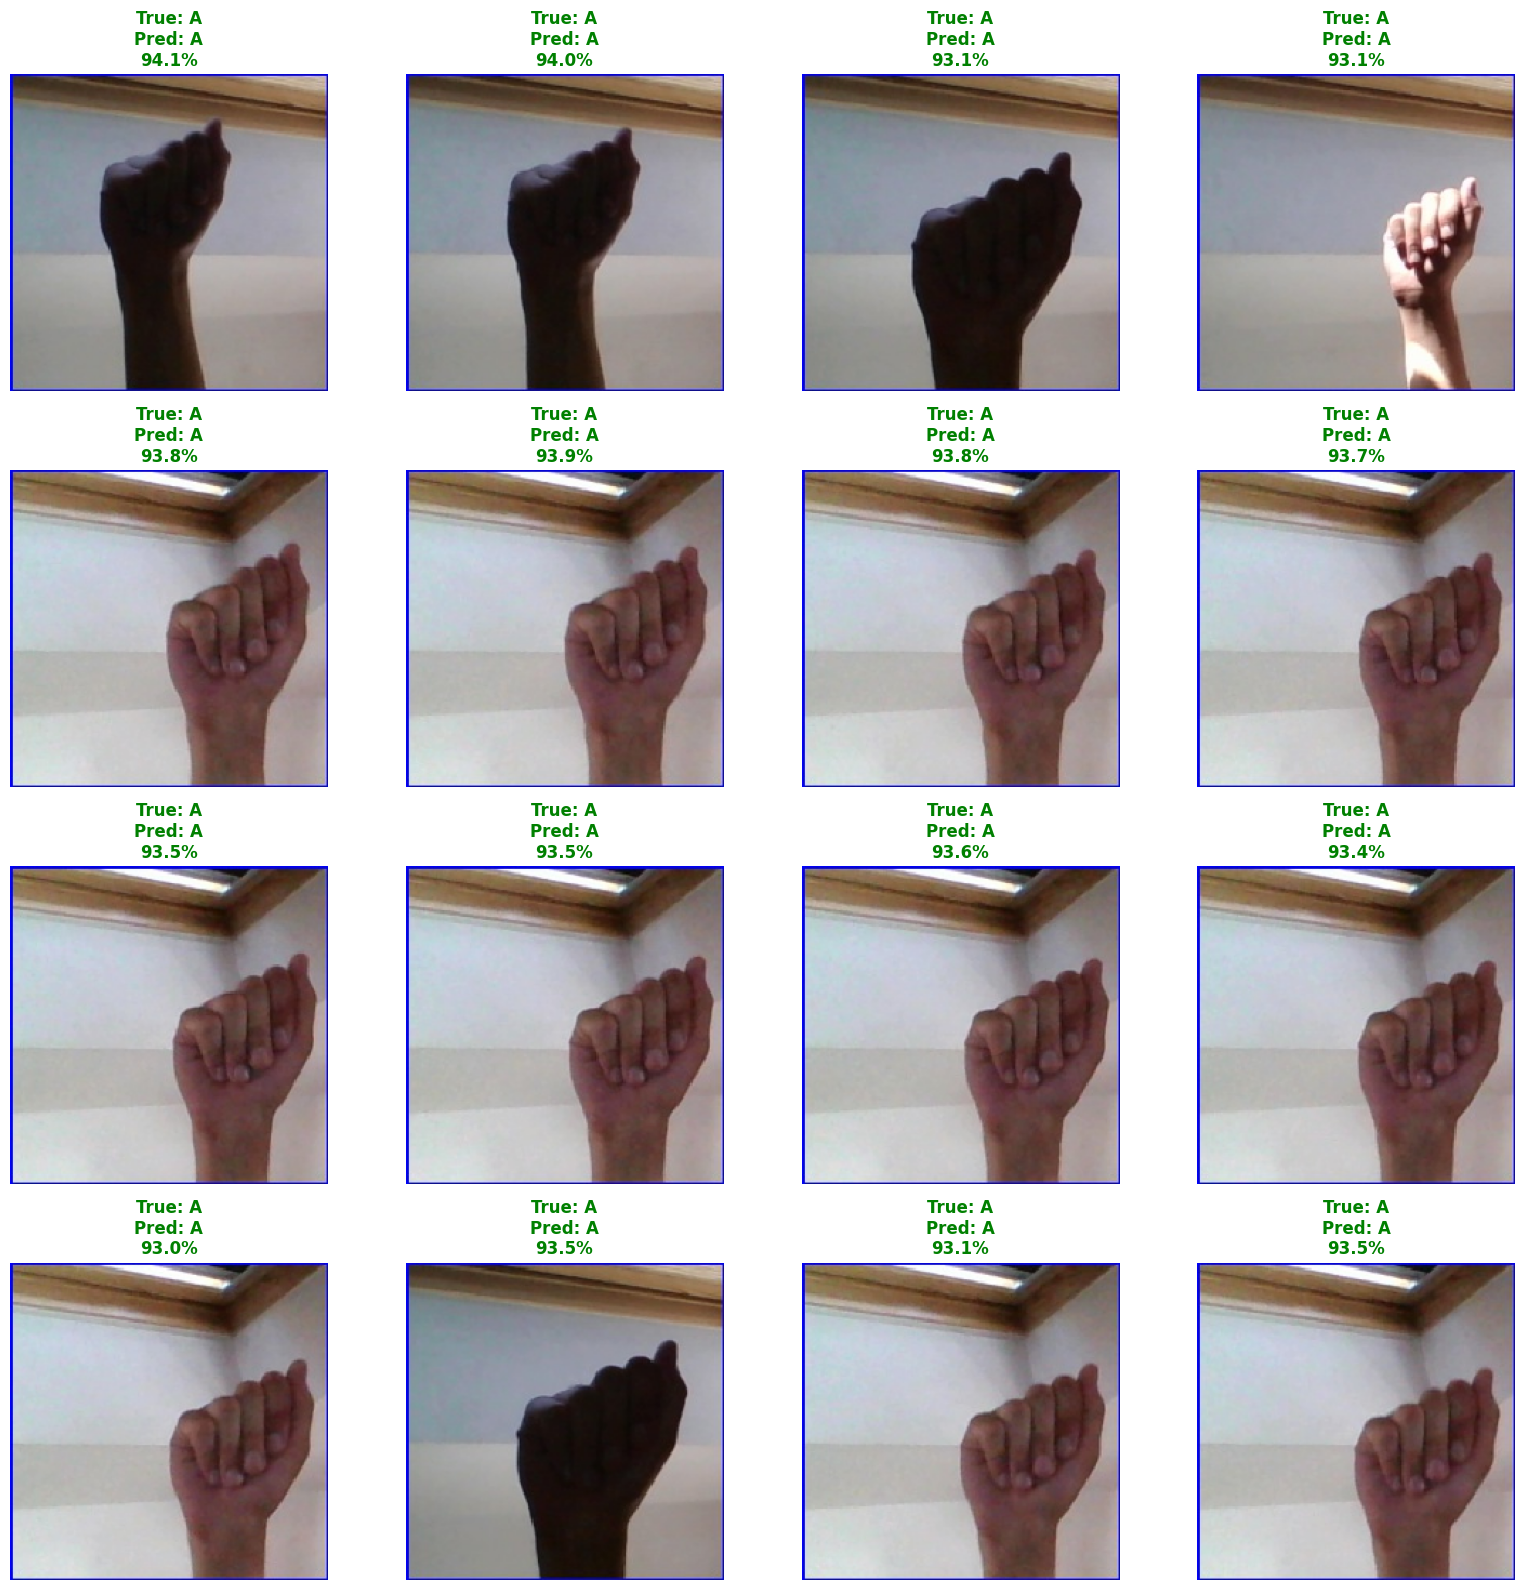

/kaggle/working/best_model_phase1.h5 (18.14 MB)
/kaggle/working/asl_model_final.h5 (33.76 MB)
/kaggle/working/best_model_final.h5 (33.76 MB)
/kaggle/working/backup_final.h5 (33.76 MB)
/kaggle/working/backup_phase1.h5 (18.14 MB)
/kaggle/working/phase1_complete.h5 (18.14 MB)
/kaggle/working/asl_model_final.keras (33.96 MB)
/kaggle/working/phase1_complete.keras (18.35 MB)
/kaggle/working/sample_predictions.png (1.58 MB)
/kaggle/working/training_history.png (0.24 MB)
/kaggle/working/confusion_matrix.png (0.45 MB)
best_model_phase1.h5 (18.14 MB)
asl_model_final.h5 (33.76 MB)
best_model_final.h5 (33.76 MB)
backup_final.h5 (33.76 MB)
backup_phase1.h5 (18.14 MB)
phase1_complete.h5 (18.14 MB)
asl_model_final.keras (33.96 MB)
phase1_complete.keras (18.35 MB)
sample_predictions.png (1.58 MB)
training_history.png (0.24 MB)
confusion_matrix.png (0.45 MB)
 TRAINING COMPLETE!
 Best Accuracy: 97.98%


In [54]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Configuration - OPTIMIZED for speed and accuracy
IMG_SIZE = 224
BATCH_SIZE = 32 
PHASE1_EPOCHS = 8 
PHASE2_EPOCHS = 15  
LEARNING_RATE = 0.001
FINE_TUNE_LR = 0.00005

# Paths
TRAIN_DIR = '/kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train'
TEST_DIR = '/kaggle/input/asl-alphabet/asl_alphabet_test/asl_alphabet_test'

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load data
print("\n Loading data...")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = valid_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

print(f"Data loaded!")
print(f"   Classes: {num_classes}")
print(f"   Training samples: {train_generator.samples}")
print(f"   Validation samples: {validation_generator.samples}")

# Build Model
def build_model(num_classes, trainable_base=False):
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    
    base_model.trainable = trainable_base
    
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(num_classes, trainable_base=False)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')]
)

print(f" Model built!")
print(f"   Total parameters: {model.count_params():,}")

# Multiple save locations for safety
callbacks_phase1 = [
    ModelCheckpoint(
        '/kaggle/working/best_model_phase1.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        '/kaggle/working/backup_phase1.h5',
        monitor='val_accuracy',
        save_best_only=False,
        mode='max',
        verbose=0
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=4,  # More aggressive
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# PHASE 1

history = model.fit(
    train_generator,
    epochs=PHASE1_EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks_phase1,
    verbose=1
)
model.save('/kaggle/working/phase1_complete.h5')
model.save('/kaggle/working/phase1_complete.keras')
print("Phase 1 saved!")

# PHASE 2: Fine-tuning
base_model.trainable = True
fine_tune_at = 80  

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Unfroze layers from {fine_tune_at} onwards")
print(f" Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')]
)

callbacks_phase2 = [
    ModelCheckpoint(
        '/kaggle/working/best_model_final.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1,
        save_weights_only=False
    ),
    ModelCheckpoint(
        '/kaggle/working/backup_final.h5',
        monitor='val_accuracy',
        save_best_only=False,
        verbose=0
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    )
]
history_fine = model.fit(
    train_generator,
    epochs=PHASE2_EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks_phase2,
    verbose=1
)

save_paths = [
    '/kaggle/working/asl_model_final.h5',
    '/kaggle/working/asl_model_final.keras',
    'asl_model_final.h5',
    'asl_model_final.keras'
]

for path in save_paths:
    try:
        model.save(path)
        if os.path.exists(path):
            size = os.path.getsize(path) / (1024*1024)
            print(f"Saved: {path} ({size:.2f} MB)")
    except Exception as e:
        print(f"Could not save to {path}: {e}")

# Combine histories
total_acc = history.history['accuracy'] + history_fine.history['accuracy']
total_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']
total_loss = history.history['loss'] + history_fine.history['loss']
total_val_loss = history.history['val_loss'] + history_fine.history['val_loss']


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(total_acc, 'b-', label='Training Accuracy', linewidth=2)
axes[0].plot(total_val_acc, 'r-', label='Validation Accuracy', linewidth=2)
axes[0].axvline(x=len(history.history['accuracy']), color='g', 
                linestyle='--', label='Fine-tuning starts', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(total_loss, 'b-', label='Training Loss', linewidth=2)
axes[1].plot(total_val_loss, 'r-', label='Validation Loss', linewidth=2)
axes[1].axvline(x=len(history.history['loss']), color='g', 
                linestyle='--', label='Fine-tuning starts', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=300, bbox_inches='tight')
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Evaluate
val_loss, val_accuracy, val_top3 = model.evaluate(validation_generator, verbose=1)
print(f"   Validation Accuracy:  {val_accuracy*100:.2f}%")
print(f"   Top-3 Accuracy:       {val_top3*100:.2f}%")
print(f"   Validation Loss:      {val_loss:.4f}")
print(f"   Training Accuracy:    {total_acc[-1]*100:.2f}%")
print(f"   Overfitting Gap:      {(total_acc[-1] - val_accuracy)*100:.2f}%")

# Confusion Matrix
validation_generator.reset()
predictions = model.predict(validation_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - {val_accuracy*100:.2f}% Accuracy', 
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300)
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# Classification Report
print("\n Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# Sample Predictions
validation_generator.reset()
x_batch, y_batch = next(validation_generator)
pred_batch = model.predict(x_batch)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.ravel()

for i in range(16):
    axes[i].imshow(x_batch[i])
    true_label = class_names[np.argmax(y_batch[i])]
    pred_label = class_names[np.argmax(pred_batch[i])]
    confidence = np.max(pred_batch[i]) * 100
    
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\n{confidence:.1f}%',
                      color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_predictions.png', dpi=300)
plt.savefig('sample_predictions.png', dpi=300)
plt.show()

# List all saved files
import glob
for pattern in ['/kaggle/working/*.h5', '/kaggle/working/*.keras', 
                '/kaggle/working/*.png', '*.h5', '*.keras', '*.png']:
    files = glob.glob(pattern)
    for f in files:
        if os.path.exists(f):
            size = os.path.getsize(f) / (1024*1024)
            print(f"{f} ({size:.2f} MB)")

print(" TRAINING COMPLETE!")
print(f" Best Accuracy: {max(total_val_acc)*100:.2f}%")
